importing packages

In [2]:
import pandas as pd 
import numpy as np 
import os
from matplotlib import pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import xgboost as xgboost
import pickle

In [3]:
#base directori

base_dir = "Telecommunications_Industry/csv files/"
csv_dir = "created csv"
model_dir = "saved models"


Reading data 
listing all col in tables

In [4]:
list_of_files = os.listdir(base_dir)


set_of_columns_awailable = set()

for file in list_of_files:

    if ".csv" in file:

        df = pd.read_csv(base_dir + file) 
        cols_in_df = df.columns.tolist() 

        set_of_columns_awailable.update(cols_in_df)
        print("columns in file :", file ,"are" , cols_in_df)
        print()

print("Total unique columns availabel in all files : " , len(set_of_columns_awailable))
print(set_of_columns_awailable)
        


columns in file : CustomerChurn.csv are ['LoyaltyID', 'Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn']

columns in file : Telco_customer_churn_services.csv are ['Service ID', 'Customer ID', 'Count', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long 

Note : each column have Customer id exept population table were the population count is corrensponding to zip codes 

Combining all table to form a whole dataset 

In [5]:

df = pd.read_csv("/home/sanket/Churnprediction/created csvTelecom_Customer_Churn_Complete.csv")

#There are two ways "Customer ID" is written in column names: one with and one without space 
#fix column name to "Customer ID" in "Telco_customer_churn.csv" file
df = df.rename(columns = {'CustomerID':'Customer ID'})

list_of_csvs = ['CustomerChurn.csv', 
                'Telco_customer_churn_demographics.csv',
                'Telco_customer_churn_location.csv',
                'Telco_customer_churn_population.csv',
                'Telco_customer_churn_services.csv',
                'Telco_customer_churn_status.csv']

for file in list_of_csvs:
    temp = pd.read_csv(base_dir + file)

    if "Customer ID" in temp.columns.tolist():
        df = pd.merge(df, temp, on = "Customer ID", how = "left", suffixes=('', '_remove'))
    else:
        df = pd.merge(df, temp, on = "Zip Code", how = "left", suffixes=('', '_remove'))
            
# remove the duplicate columns
df.drop([i for i in df.columns if 'remove' in i], axis = 1, inplace = True)

print("Total Number of columns : ", len(df.columns))
print("List of columns :", df.columns.tolist())
df.head()

Total Number of columns :  65
List of columns : ['Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'LoyaltyID', 'Tenure', 'Churn', 'Age', 'Under 30', 'Married', 'Number of Dependents', 'Location ID', 'ID', 'Population', 'Service ID', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Avg Monthly Long Distance Charges', 'Internet Type', 'Avg Monthly GB Download', 'Device Protection Plan', 'Premium Tech Support', 'Streaming Music', 'Unlimited Data', 'Monthly Charge', 'Total Refunds', 'Total Extra Data Charges', 'Total Lon

,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Unlimited Data,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Status ID,Satisfaction Score,Customer Status,Churn Category
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,53.85,0.0,0,20.94,129.09,SUDNGT6444,1,Churned,Competitor
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,70.70,0.0,0,18.24,169.89,KZSZDV8891,2,Churned,Other
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,99.65,0.0,0,97.20,917.70,EPTIUU1269,3,Churned,Other
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,104.80,0.0,0,136.92,3182.97,PAJIVH8196,3,Churned,Other
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,103.70,0.0,0,2172.17,7208.47,RXFOMV1173,1,Churned,Competitor


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 65 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Country                            7043 non-null   object 
 3   State                              7043 non-null   object 
 4   City                               7043 non-null   object 
 5   Zip Code                           7043 non-null   int64  
 6   Lat Long                           7043 non-null   object 
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Gender                             7043 non-null   object 
 10  Senior Citizen                     7043 non-null   object 
 11  Partner                            7043 non-null   objec

In [7]:
df.to_csv(csv_dir + "Telecom_Customer_Churn_Complete.csv")

#saving all atributes in one single csv file 


DATA preproccing 

Dealing with Null Values :
**Observations:** when we see the overview of dataset using df.info() we can see the datatypes of all the columns and we can also observe that all the columns have 7043 (all) not null values except the "Churn Category" and "Churn Reason" columns because they contain the reason why customer churned and how and they are only available for users that have left (churned). We can fill the null values with the constant value of "Not Churned" or "Not Applicable". - This column can be used for EDA.

In [8]:
columns_with_null_values = [(col , df[col].isnull().sum())for col in df.columns.tolist() if df[col].isnull().sum() > 0]
print("Columns with null values and their count : " , columns_with_null_values)

Columns with null values and their count :  [('Churn Reason', np.int64(5174)), ('Offer', np.int64(3877)), ('Internet Type', np.int64(1526)), ('Churn Category', np.int64(5174))]


In [9]:
df["Churn Category"].fillna("Not Applicable", inplace = True)


# replacing na values in "Churn Reason" with "Not Churned"
df["Churn Reason"].fillna("Not Churned", inplace = True)

/tmp/ipykernel_11259/3989317782.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Churn Category"].fillna("Not Applicable", inplace = True)
/tmp/ipykernel_11259/3989317782.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [10]:
# Fill remaining null values in other columns
df["Offer"].fillna("No Offer", inplace=True)
df["Internet Type"].fillna("No Internet", inplace=True)

# Verify all null values are handled
print("Null values remaining:")
print(df.isnull().sum().sum())

Null values remaining:
0


/tmp/ipykernel_11259/3810135505.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Offer"].fillna("No Offer", inplace=True)
/tmp/ipykernel_11259/3810135505.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [11]:
for col in df.columns.tolist():
    print(col)
    print("Number of unique values:", df[col].nunique())
    print("Unique Values:", df[col].unique()[:10])
    
    if(df[col].dtype == 'int64' or df[col].dtype == 'float64'):
        print("max :", df[col].max())
        print("min :", df[col].min())

    print()

Customer ID
Number of unique values: 7043
Unique Values: ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' '7892-POOKP' '0280-XJGEX'
 '4190-MFLUW' '8779-QRDMV' '1066-JKSGK' '6467-CHFZW' '8665-UTDHZ']

Count
Number of unique values: 1
Unique Values: [1]
max : 1
min : 1

Country
Number of unique values: 1
Unique Values: ['United States']

State
Number of unique values: 1
Unique Values: ['California']

City
Number of unique values: 1129
Unique Values: ['Los Angeles' 'Beverly Hills' 'Huntington Park' 'Lynwood'
 'Marina Del Rey' 'Inglewood' 'Santa Monica' 'Torrance' 'Whittier'
 'La Habra']

Zip Code
Number of unique values: 1652
Unique Values: [90003 90005 90006 90010 90015 90020 90022 90024 90028 90029]
max : 96161
min : 90001

Lat Long
Number of unique values: 1652
Unique Values: ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 '34.062125, -118.315709' '34.039224, -118.266293'
 '34.066367, -118.309868' '34.02381, -118.156582' '34.066303, -118.435479'
 '34.099869, -118.326

***replacing column values and group values in bins***

In [12]:
#columns in which we want ti replace "No internet service" with "NO"ArithmeticError

cols_to_change = ["Online Security","Online Backup", "Device Protection", "Streaming TV" , "Streaming Movies"]

#applyting that change to all the columns in list "cols_to_change"
df[cols_to_change] = np.where(df[cols_to_change] == "No internet service", "No" , df[cols_to_change])


#for "Multiple Lines" column
df["Multiple Lines"] = np.where(df["Multiple Lines"] == "No phone service", "No", df["Multiple Lines"])

cols_to_change



['Online Security',
 'Online Backup',
 'Device Protection',
 'Streaming TV',
 'Streaming Movies']

In [13]:
#group tenure in bins 
df["Tenure Bins"] = pd.cut(df['Tenure in Months'], [0, 12, 24, 48, 60, 72])
df.value_counts("Tenure Bins")

Tenure Bins
(0, 12]     2186
(24, 48]    1594
(60, 72]    1407
(12, 24]    1024
(48, 60]     832
Name: count, dtype: int64

**converting nums as strings into integerse**

In [14]:
df["Population"] = df['Population'].str.replace(',','').astype(int)

##REMOVING uneccessary columns

we can observe some columns that contain IDs represent some unique IDs correnspoding to users - let's look at then one by one and figure out if our model will be able to extract any inforamtion from those attributes or not. and there are also columns that same value for all users so there is no insformation to be learned tnited States - so state and country in our case are useless

In [15]:
#listing all columns with more than 20 unique values
for col in df.columns.tolist():
    if df[col].nunique() > 20:
        print(col, "has", df[col].nunique(), "unique values")


list_of_columns_to_drop = []

Customer ID has 7043 unique values
City has 1129 unique values
Zip Code has 1652 unique values
Lat Long has 1652 unique values
Latitude has 1652 unique values
Longitude has 1651 unique values
Tenure Months has 73 unique values
Monthly Charges has 1585 unique values
Total Charges has 6531 unique values
Churn Score has 85 unique values
CLTV has 3438 unique values
Churn Reason has 21 unique values
LoyaltyID has 7021 unique values
Tenure has 73 unique values
Age has 62 unique values
Location ID has 7043 unique values
ID has 1652 unique values
Population has 1592 unique values
Service ID has 7043 unique values
Tenure in Months has 72 unique values
Avg Monthly Long Distance Charges has 3584 unique values
Avg Monthly GB Download has 50 unique values
Monthly Charge has 1585 unique values
Total Refunds has 500 unique values
Total Long Distance Charges has 6068 unique values
Total Revenue has 6975 unique values
Status ID has 7043 unique values


#### Costemer ID

In [16]:
#Costomer ID attrbute is not useful for prediction, so we can drop it
print(df["Customer ID"].head())
print("\n Number of Unique Values:", df["Customer ID"].nunique())

0    3668-QPYBK
1    9237-HQITU
2    9305-CDSKC
3    7892-POOKP
4    0280-XJGEX
Name: Customer ID, dtype: object

 Number of Unique Values: 7043


In [17]:
#we can see that all values of that columns are have unique strings - just for identification of user
#which does not have clear interpretation and help us determine if a customer churn or not

if "Customer ID" in df.columns:
    df.set_index("Customer ID", inplace=True)
else:
    print("'Customer ID' column not found in DataFrame. Check column names or CSV loading.")

In [18]:
#couting for attribute
print(df["Count"].head())
print("\n Number of Unique Values", df["Count"].nunique())

Customer ID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
Name: Count, dtype: int64

 Number of Unique Values 1


In [19]:
#opposite of costumer ID has the same value for each and every user regardless of whether they churn or not

if 'list_of_columns_to_drop' not in globals():
    list_of_columns_to_drop = []

list_of_columns_to_drop.append("Count")

### Country 


In [20]:
#country attribute
print(df["Country"].head())
print("\n Nuber of unique values :" , df["Country"].nunique())


Customer ID
3668-QPYBK    United States
9237-HQITU    United States
9305-CDSKC    United States
7892-POOKP    United States
0280-XJGEX    United States
Name: Country, dtype: object

 Nuber of unique values : 1


In [21]:
#same as count value for all users - nothing to lern 
list_of_columns_to_drop.append("Country")

### state

In [22]:
#state Attribtue
print(df["State"].head())
print("\n Number of unique values ;" , df["State"].nunique())


Customer ID
3668-QPYBK    California
9237-HQITU    California
9305-CDSKC    California
7892-POOKP    California
0280-XJGEX    California
Name: State, dtype: object

 Number of unique values ; 1


In [23]:
#it having same state for all users - noting to learn from list so we can drop it 
list_of_columns_to_drop.append("State") 


### Churn labels 


In [24]:
#churn label attribute
print(df["Churn Label"].head())
print("\n Number of Unique values", df["Churn Label"].nunique())

Customer ID
3668-QPYBK    Yes
9237-HQITU    Yes
9305-CDSKC    Yes
7892-POOKP    Yes
0280-XJGEX    Yes
Name: Churn Label, dtype: object

 Number of Unique values 2


In [25]:
(df["Churn"] == df["Churn Label"]).all()

np.True_

In [26]:
#this column has exact same values as churn column 
list_of_columns_to_drop.append("Churn Lable")

### Location ID 

In [27]:
print(df["Location ID"].head())
print("\n Number of unique values :", df["Location ID"].nunique())


Customer ID
3668-QPYBK    PZZUIT6837
9237-HQITU    CKNALR2542
9305-CDSKC    VCQKYE1638
7892-POOKP    SNLISG8671
0280-XJGEX    YTSGZA8582
Name: Location ID, dtype: object

 Number of unique values : 7043


** We can see that there all the values in thise column are unique strings - co-ordination will be more be more usefull for undestrding location info, which so not a clear interpretaion and cannot help use det **


In [28]:
list_of_columns_to_drop.append("Locaiton ID")


In [29]:
#ID attribute 
print(df["ID"].head())
print("\n Number of Unique Values ", df["ID"].nunique())


Customer ID
3668-QPYBK     3
9237-HQITU     5
9305-CDSKC     6
7892-POOKP     9
0280-XJGEX    14
Name: ID, dtype: int64

 Number of Unique Values  1652


In [30]:
#Accoding to the defination of column given in dataset - thise column was just used to identify row number in population table 
#and does not corresponf to any about our user 

list_of_columns_to_drop.append("ID")

### Service ID

In [31]:
#Service ID Attribute 
print(df['Service ID'].head())
print("\n Number of Unique Values ", df["Service ID"].nunique())


Customer ID
3668-QPYBK    ZLZTZWPWE3351
9237-HQITU    GXJVSQIYH4715
9305-CDSKC    KDUHHRQBI5663
7892-POOKP    WXXQTNEZW3786
0280-XJGEX    LTNFDWAMC2575
Name: Service ID, dtype: object

 Number of Unique Values  7043


In [32]:
#just used to idnetify in rows in service table - does not have convey and meaning about user 
list_of_columns_to_drop.append("Service ID")

### Quater

In [33]:
#Quater attribute 
print(df["Quarter"].head())
print("\n Nunber of unique values ", df["Quarter"].nunique())

Customer ID
3668-QPYBK    Q3
9237-HQITU    Q3
9305-CDSKC    Q3
7892-POOKP    Q3
0280-XJGEX    Q3
Name: Quarter, dtype: object

 Nunber of unique values  1


In [34]:
#same count - same value for all user - ni info to be extracted 
list_of_columns_to_drop.append("Quarter")

### Stutus ID

In [35]:
#for Status ID attribute
print(df["Status ID"].head())
print("\n Number of Unique Values ", df["Status ID"].nunique())


Customer ID
3668-QPYBK    SUDNGT6444
9237-HQITU    KZSZDV8891
9305-CDSKC    EPTIUU1269
7892-POOKP    PAJIVH8196
0280-XJGEX    RXFOMV1173
Name: Status ID, dtype: object

 Number of Unique Values  7043


In [36]:
#we can see that there all the values in thise column are unque strings 
#whcih so nit have a cleat intepretaion and cannot be get helpforl ofr determinr if a costumer eill make churn or nit 
list_of_columns_to_drop.append("Status ID")

### Loyalty ID 


In [37]:
#Loyalty ID Attribute
print(df["LoyaltyID"].head())
print("\n Number of Unique values ", df["LoyaltyID"].nunique())


Customer ID
3668-QPYBK    326527
9237-HQITU    503388
9305-CDSKC    160192
7892-POOKP    582674
0280-XJGEX    933642
Name: LoyaltyID, dtype: int64

 Number of Unique values  7021


In [38]:
#here also we can see all values are unique strings for in thise column are unique numbers
#with not so cleat intepretain and cannot help us determine if a custemer will make churn or  not 
list_of_columns_to_drop.append("LoyaltyID")

#### Some others - duplicate columns, have same info, data leakage

- "Tenure Months", "Tenure" and "Tenure in Months" - check definations in dataset
       - they are almost the same but we have better description of "Tenure in Months" in dataset so we'll keep that


In [39]:
list_of_columns_to_drop.append("Tenure")
list_of_columns_to_drop.append("Tenure Months")
list_of_columns_to_drop.append("Churn")
list_of_columns_to_drop.append("Internet Type")
list_of_columns_to_drop.append("Monthly Charge")
list_of_columns_to_drop.append("Tenure in Months")

In [40]:
list_of_columns_to_drop.append("Lat Long")
list_of_columns_to_drop.append("Zip Code")
list_of_columns_to_drop.append("City")

in that dataset provide we have 2 column "Churn reason" and "Churn Category" which contain informatin will not be awailable to us before churning fucture prediction 

"Customer Status" is also sourse of data as lekage as if indicate whether customer will stay leave of join at end 


In [41]:
list_of_columns_to_drop.append("Churn Reason")
list_of_columns_to_drop.append("Churn Category")
list_of_columns_to_drop.append("Customer Status")
list_of_columns_to_drop.append("CLTV")
list_of_columns_to_drop.append("Churn Score")

#### Remove / drop not useful columns from table / dataframe


In [42]:
list_of_columns_to_drop

['Count',
 'Country',
 'State',
 'Churn Lable',
 'Locaiton ID',
 'ID',
 'Service ID',
 'Quarter',
 'Status ID',
 'LoyaltyID',
 'Tenure',
 'Tenure Months',
 'Churn',
 'Internet Type',
 'Monthly Charge',
 'Tenure in Months',
 'Lat Long',
 'Zip Code',
 'City',
 'Churn Reason',
 'Churn Category',
 'Customer Status',
 'CLTV',
 'Churn Score']

In [43]:
# Drop columns only if they exist in the DataFrame to avoid KeyError
cols_to_drop = [col for col in list_of_columns_to_drop if col in df.columns]
missing_cols = [col for col in list_of_columns_to_drop if col not in df.columns]

if cols_to_drop:
    df.drop(cols_to_drop, axis=1, inplace=True)
    print(f"Dropped columns: {cols_to_drop}")
if missing_cols:
    print(f"Columns not found and not dropped: {missing_cols}")

Dropped columns: ['Count', 'Country', 'State', 'ID', 'Service ID', 'Quarter', 'Status ID', 'LoyaltyID', 'Tenure', 'Tenure Months', 'Churn', 'Internet Type', 'Monthly Charge', 'Tenure in Months', 'Lat Long', 'Zip Code', 'City', 'Churn Reason', 'Churn Category', 'Customer Status', 'CLTV', 'Churn Score']
Columns not found and not dropped: ['Churn Lable', 'Locaiton ID']


In [44]:
#Add a new column to represent Satisfaction score as categorical variable for EDA 
df['Satisfaction Score Label'] = df['Satisfaction Score'].astype('category')

In [45]:
#rename the target column "Churn Value" to just "Churn"
df.rename(columns = {'Churn Value' : 'Churn'}, inplace = True)

In [46]:
df.to_csv(csv_dir + "Selected_columns_customer_churn.csv")

In [47]:
df.head()


,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,...,Premium Tech Support,Streaming Music,Unlimited Data,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Tenure Bins,Satisfaction Score Label
Customer ID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,33.964131,-118.272783,Male,No,No,No,Yes,No,DSL,Yes,...,No,No,Yes,0.0,0,20.94,129.09,1,"(0, 12]",1
9237-HQITU,34.059281,-118.307420,Female,No,No,Yes,Yes,No,Fiber optic,No,...,No,No,Yes,0.0,0,18.24,169.89,2,"(0, 12]",2
9305-CDSKC,34.048013,-118.293953,Female,No,No,Yes,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,0.0,0,97.20,917.70,3,"(0, 12]",3
7892-POOKP,34.062125,-118.315709,Female,No,Yes,Yes,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,0.0,0,136.92,3182.97,3,"(24, 48]",3
0280-XJGEX,34.039224,-118.266293,Male,No,No,Yes,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,0.0,0,2172.17,7208.47,1,"(48, 60]",1


# EDA (Exploratory Data Analysis)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Latitude                           7043 non-null   float64 
 1   Longitude                          7043 non-null   float64 
 2   Gender                             7043 non-null   object  
 3   Senior Citizen                     7043 non-null   object  
 4   Partner                            7043 non-null   object  
 5   Dependents                         7043 non-null   object  
 6   Phone Service                      7043 non-null   object  
 7   Multiple Lines                     7043 non-null   object  
 8   Internet Service                   7043 non-null   object  
 9   Online Security                    7043 non-null   object  
 10  Online Backup                      7043 non-null   object  
 11  Device Protection                

# Univariate analysis

## Distibution of target lable - "Churn"

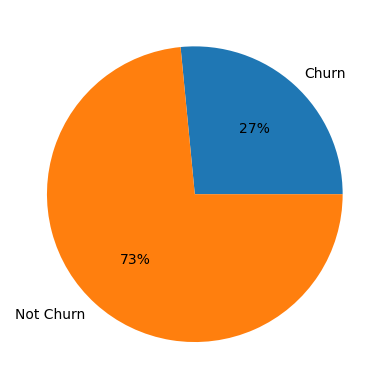

In [49]:
#let's take a look at our target label - "Churn" first
counts = [(df["Churn"] == 1).sum(), (df["Churn"] == 0).sum()]
plt.pie(counts, labels = ["Churn", "Not Churn"], autopct='%.0f%%')
plt.show()


### Bar plots of categorical variables

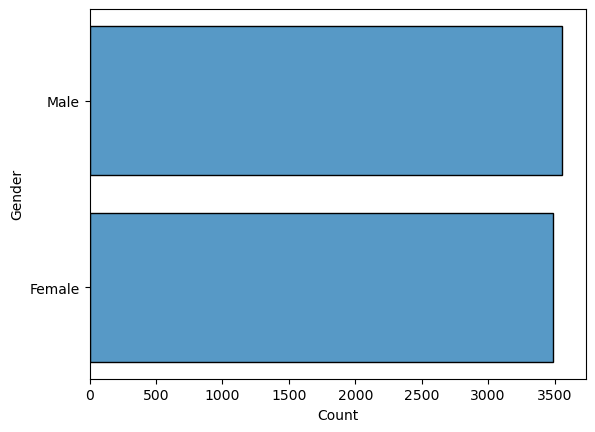

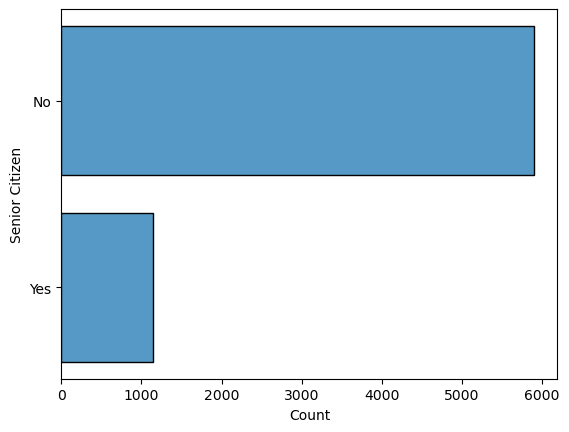

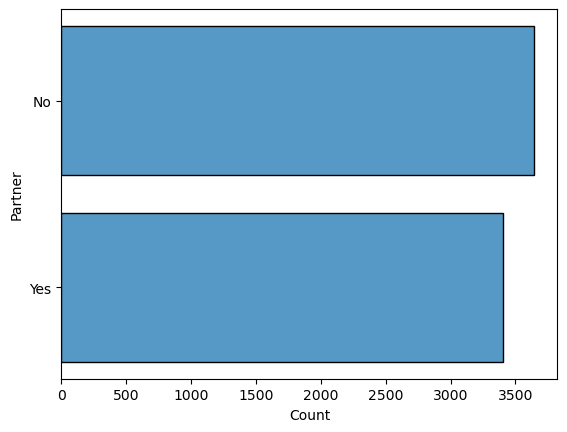

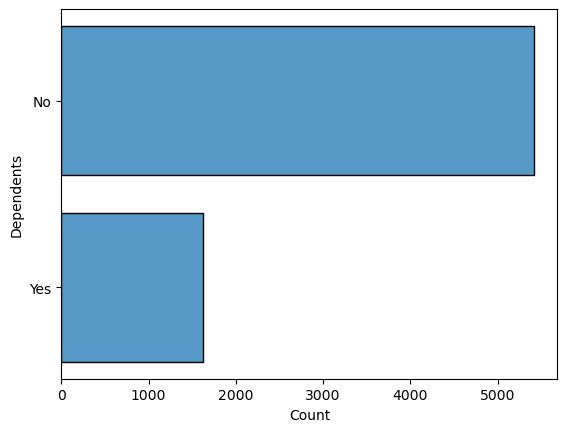

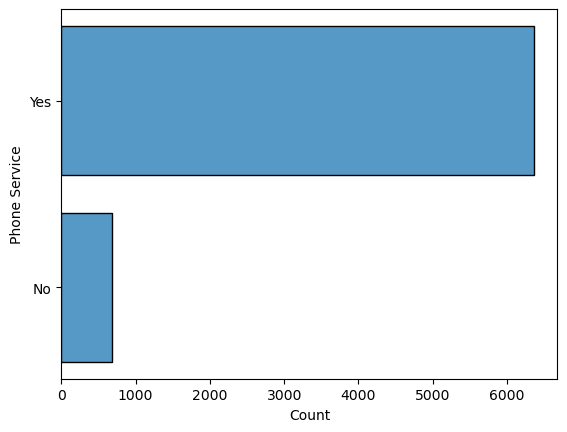

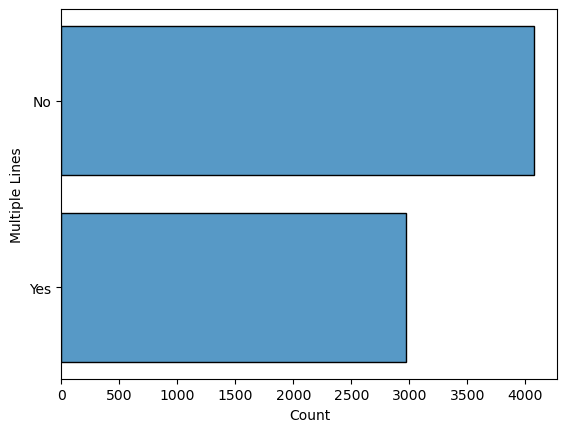

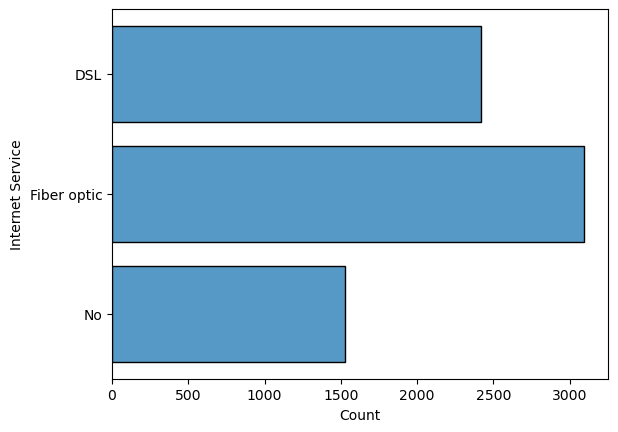

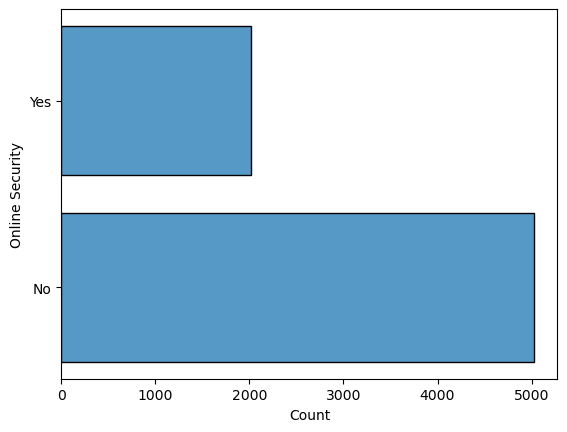

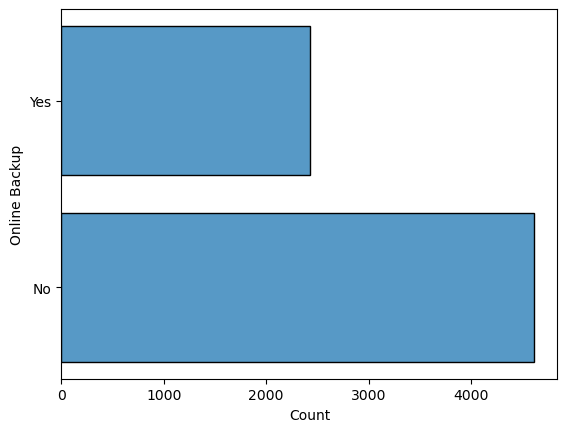

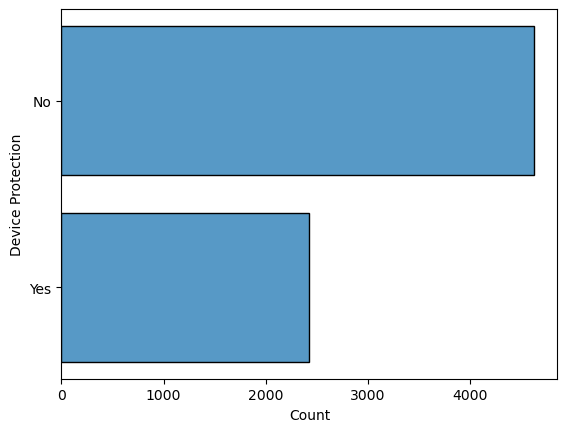

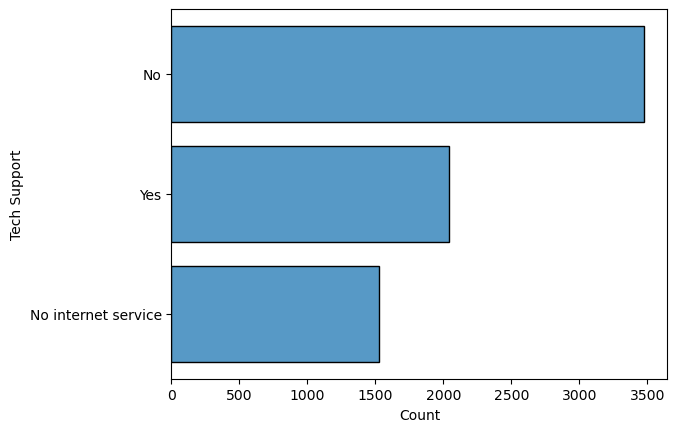

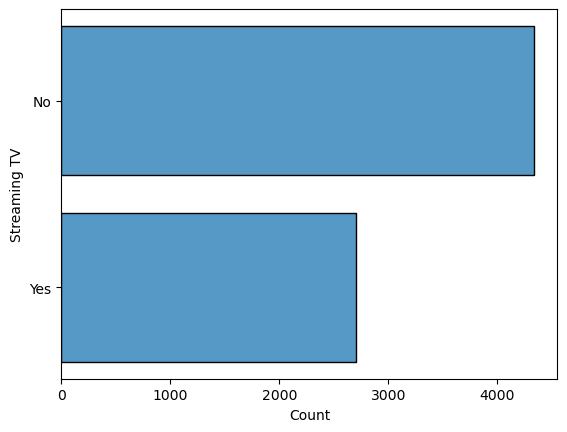

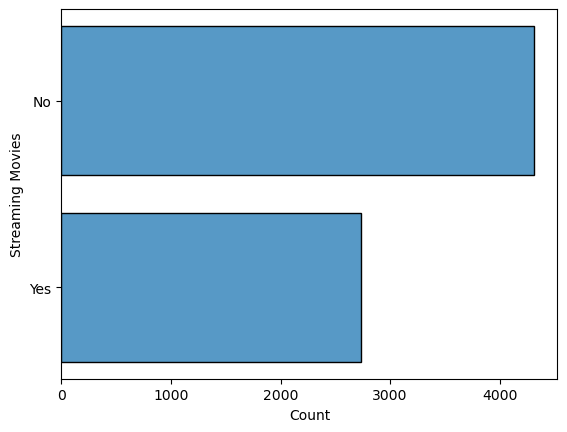

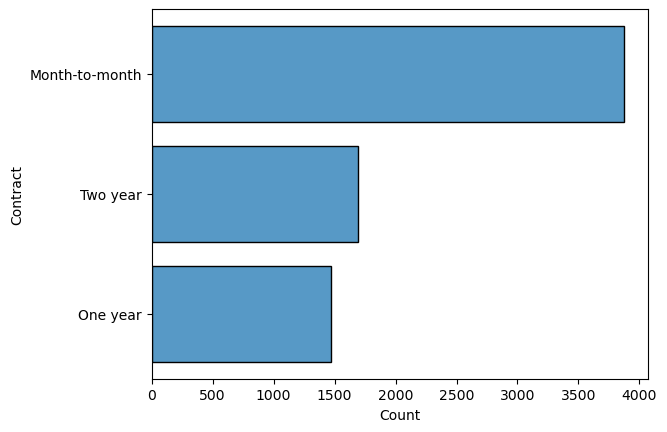

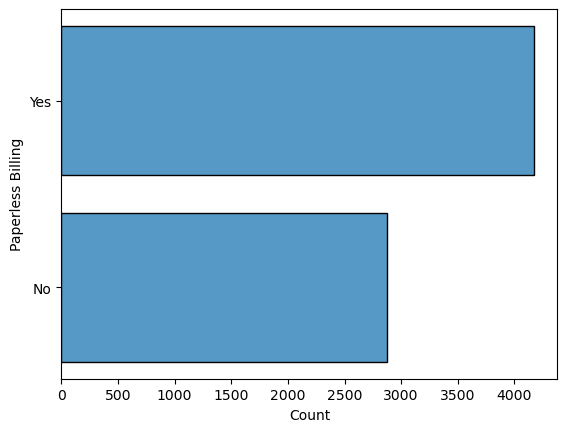

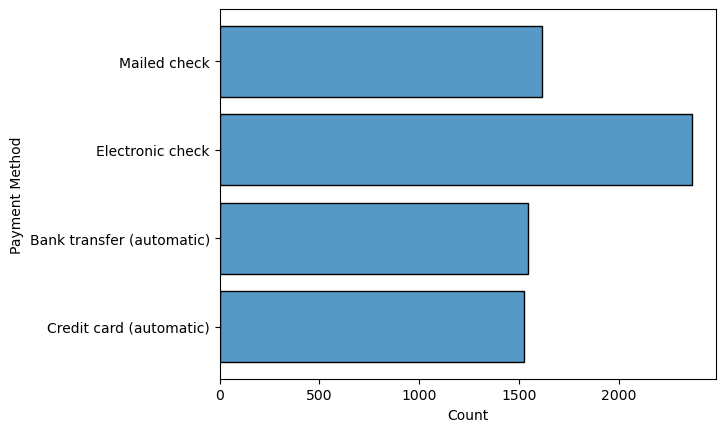

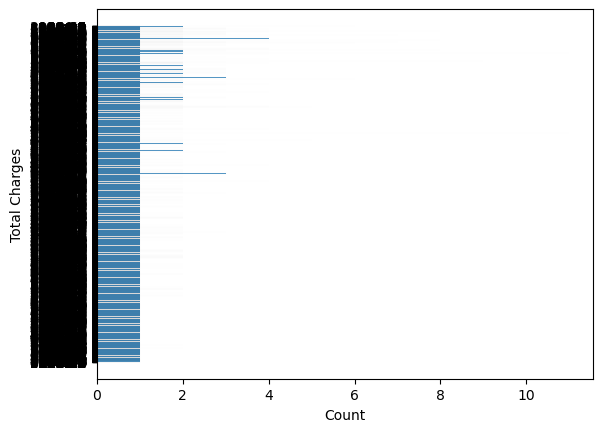

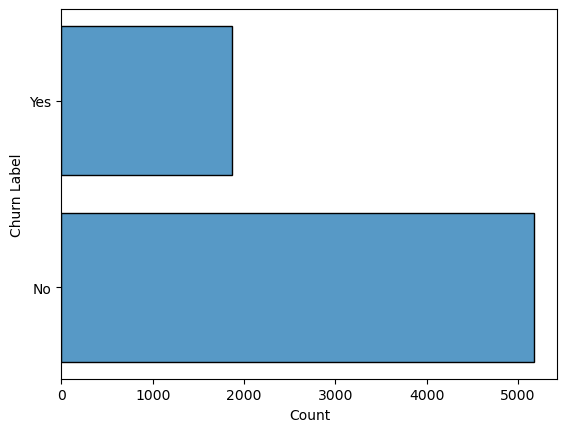

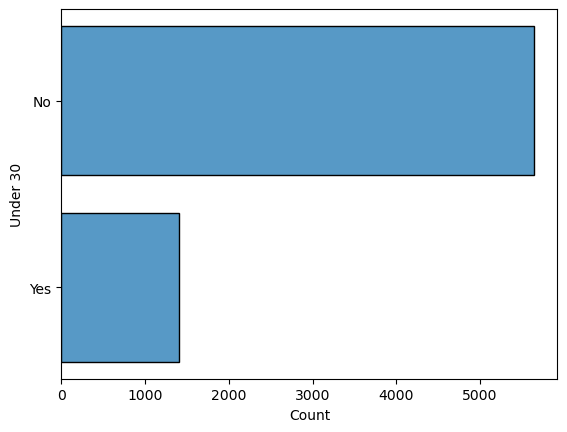

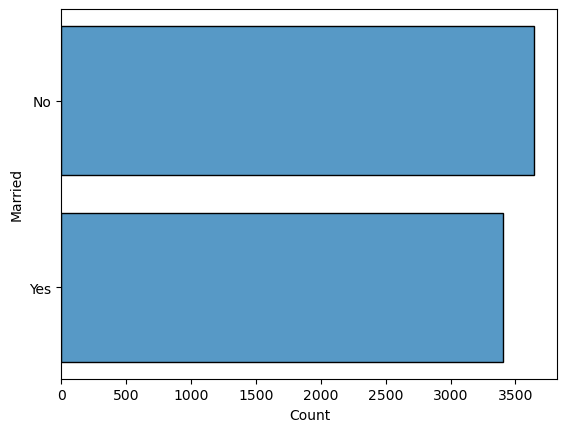

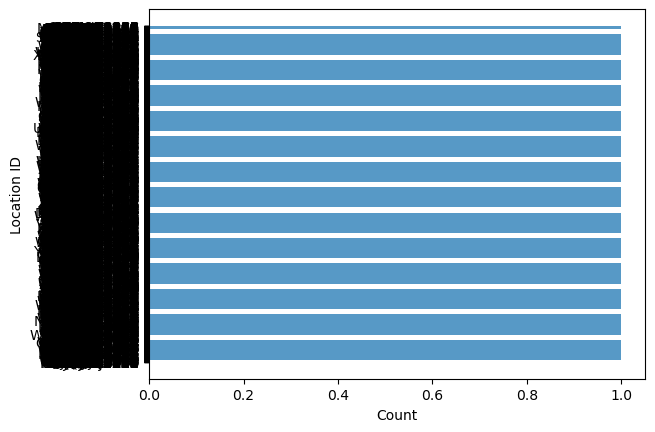

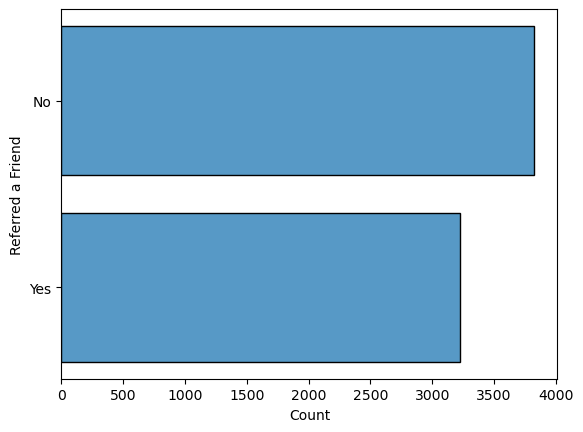

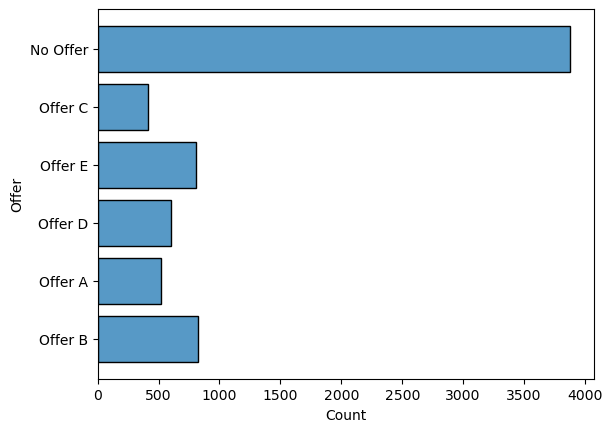

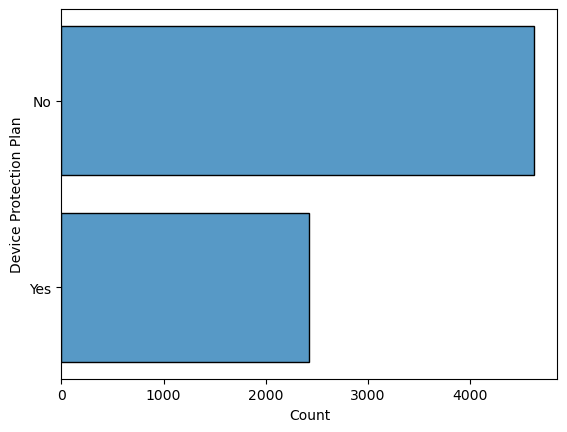

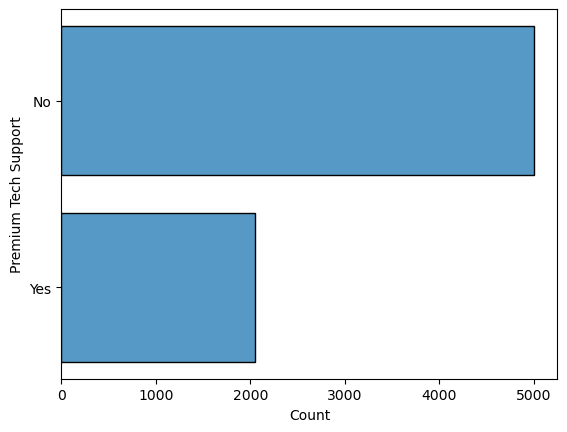

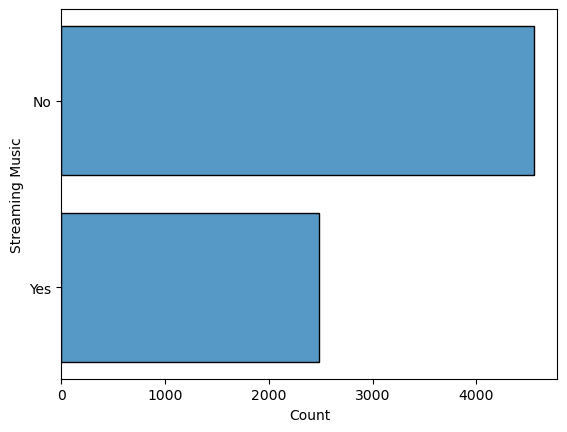

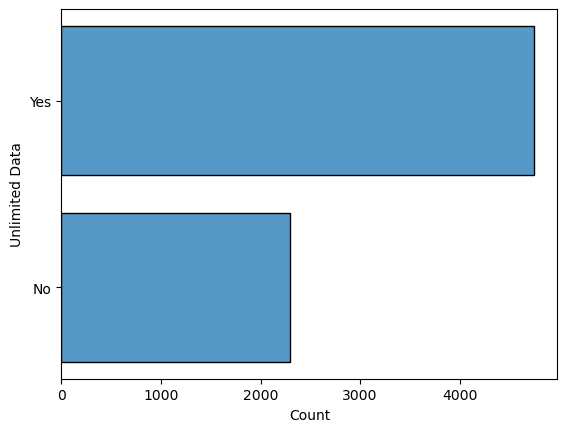

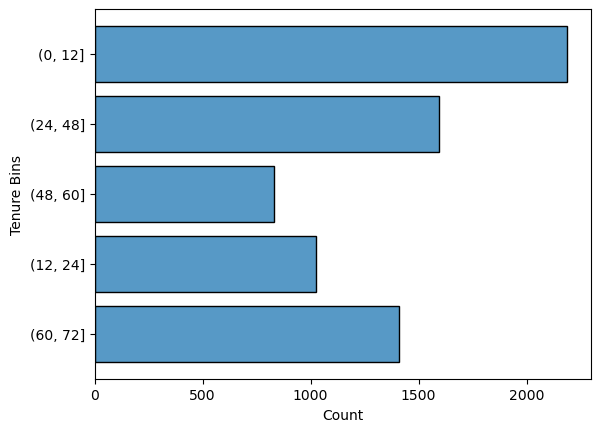

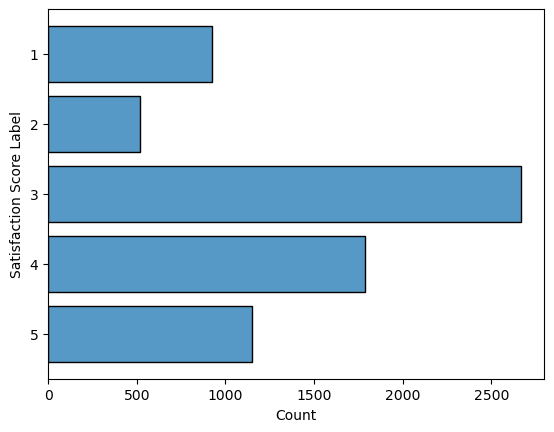

In [50]:
for col in df.columns.tolist():
    if(df[col].dtype == 'object'):
        plt.figure()
        sns.histplot(data = df, y = col, shrink=0.8)
        plt.show()
    elif df[col].dtype == 'category':
        temp = df.copy()
        temp[col] = df[col].astype(str)
        plt.figure()
        sns.histplot(data = temp, y = col, shrink=0.8)
        plt.show()
        

All of the categorical variable seem to have a resonably broad distribution, therefore, all of them will be kept for furhter analysis.

### Churn coorespoding to differant values of attribute / columns 

i then went to see how other catogorical column varied with churn columns 

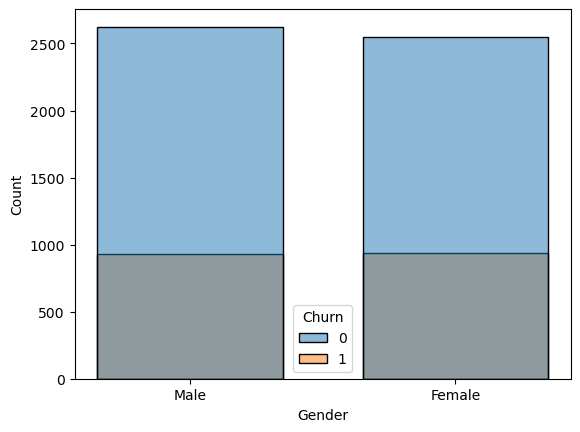

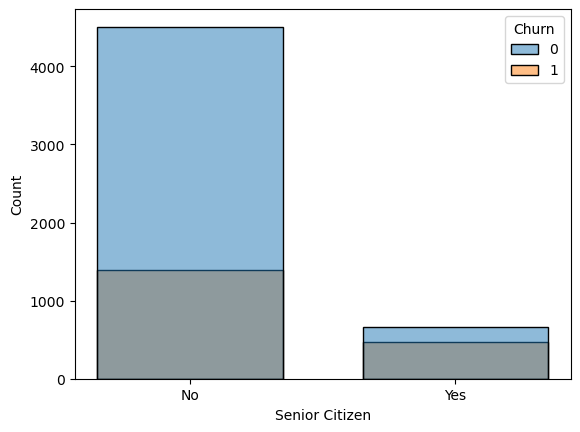

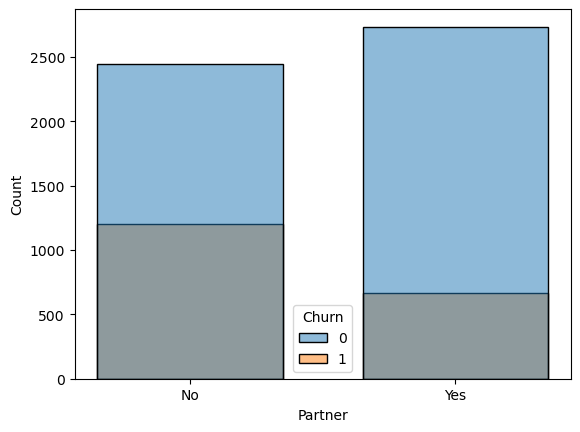

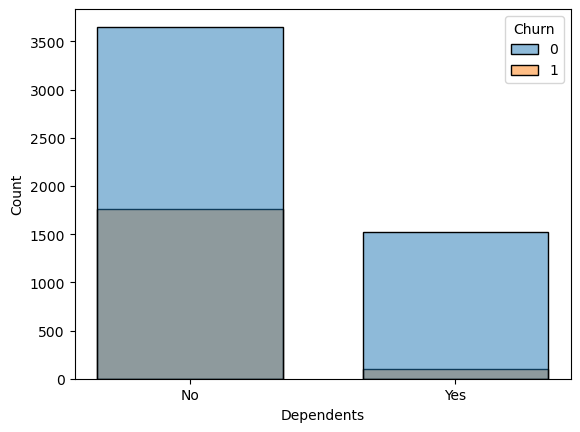

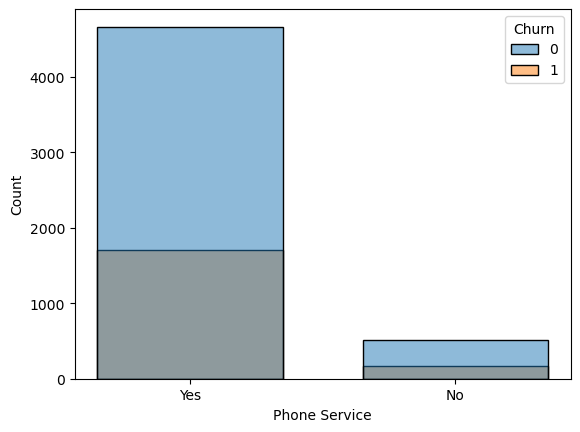

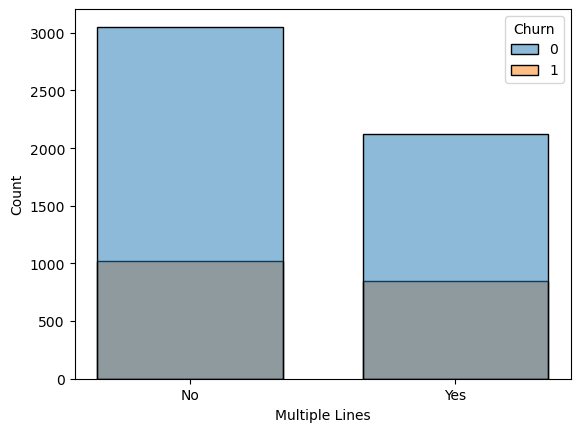

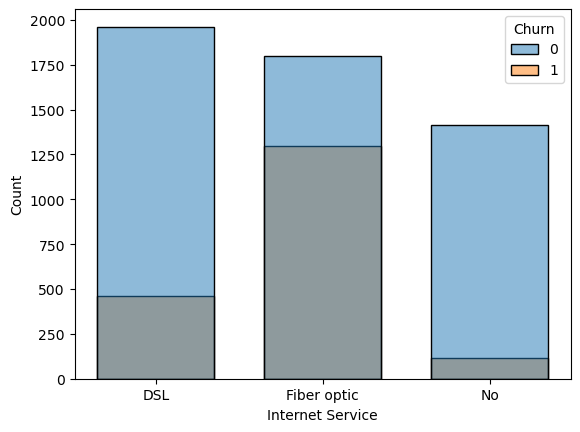

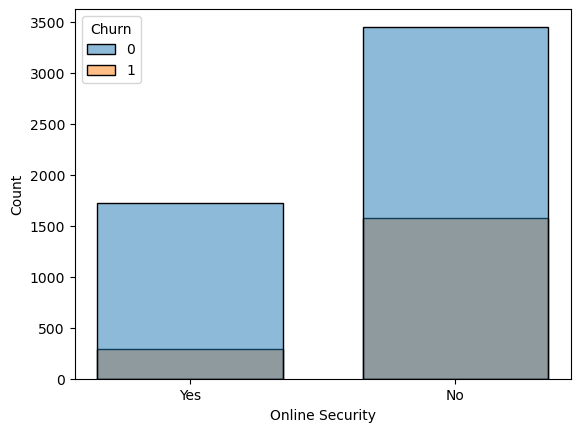

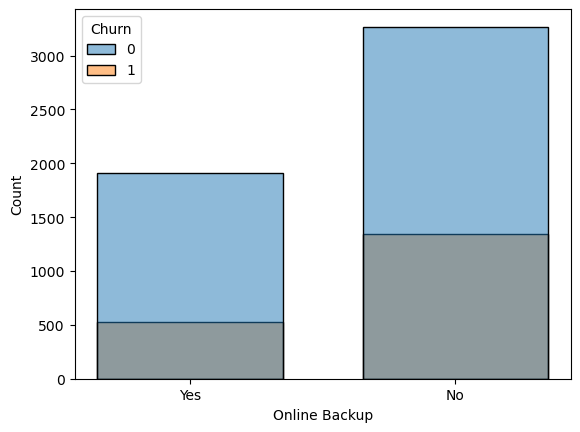

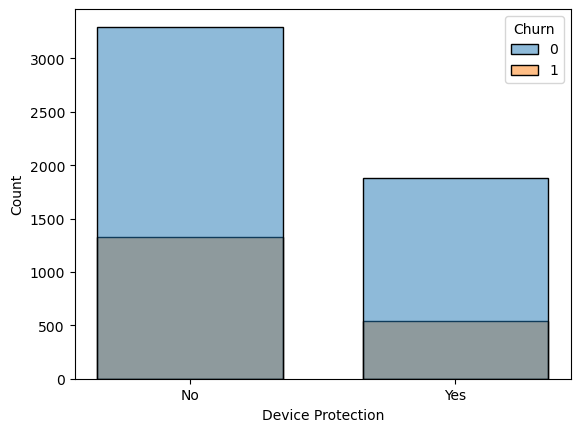

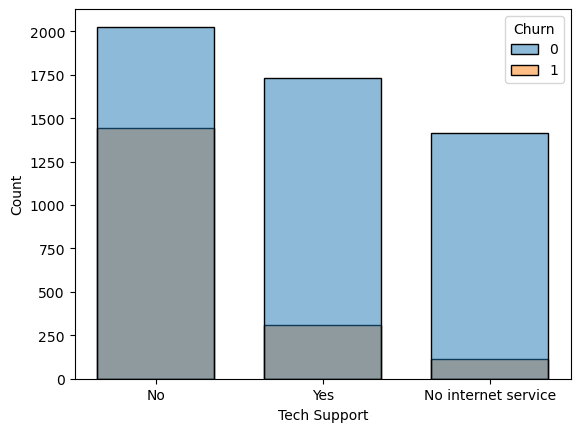

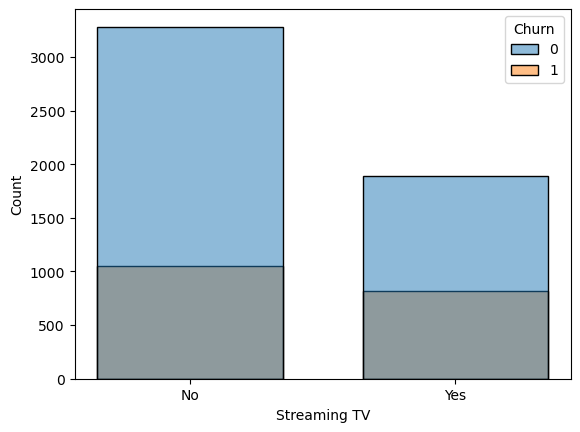

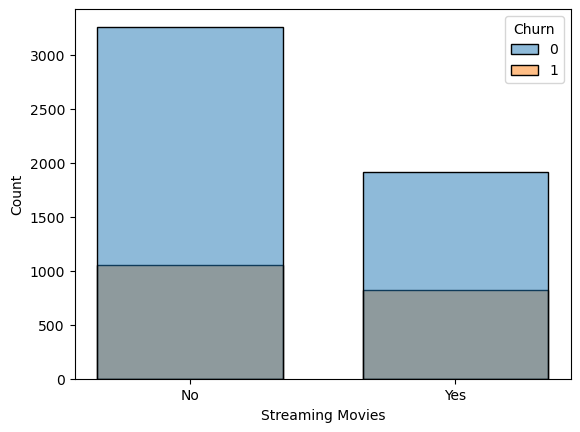

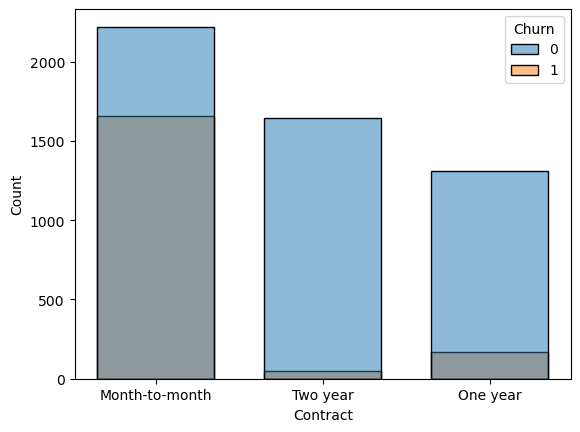

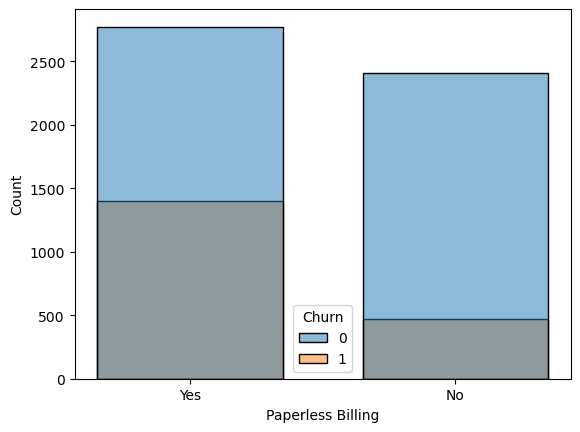

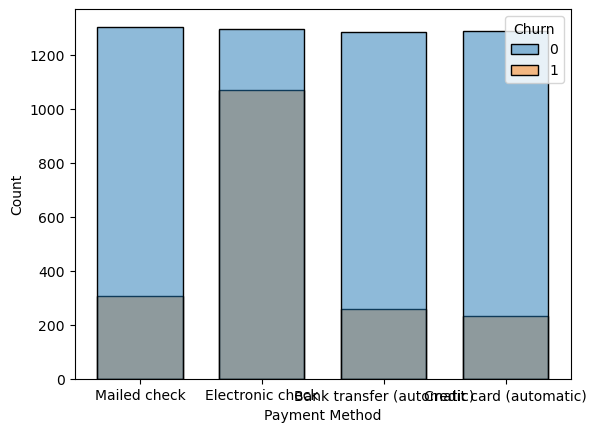

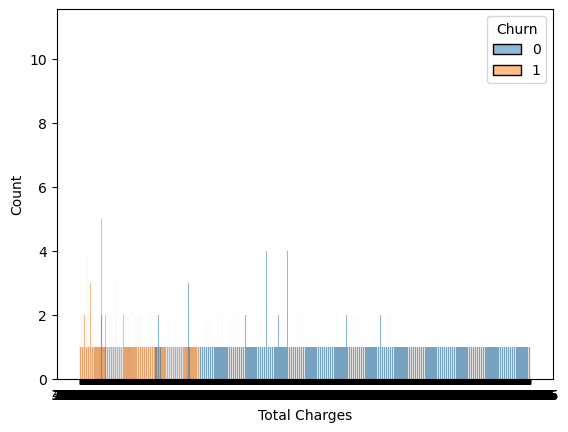

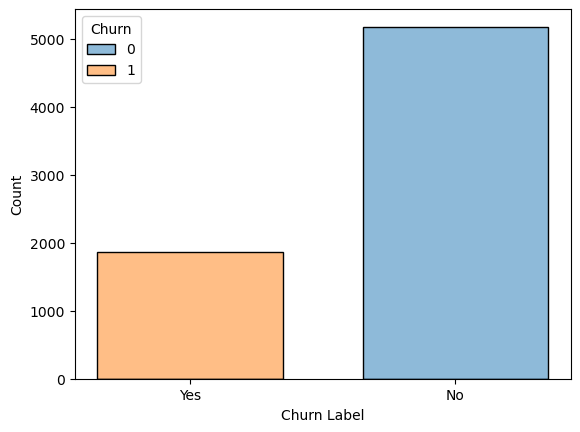

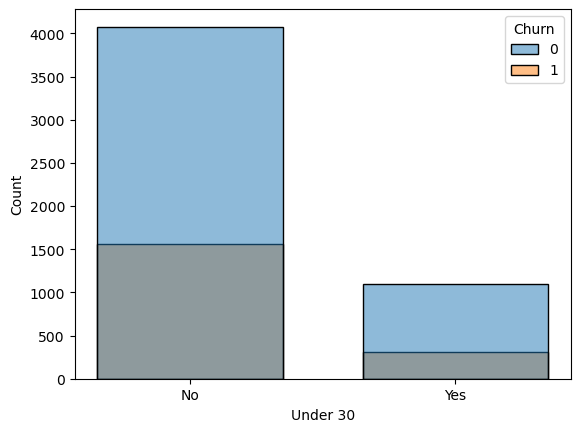

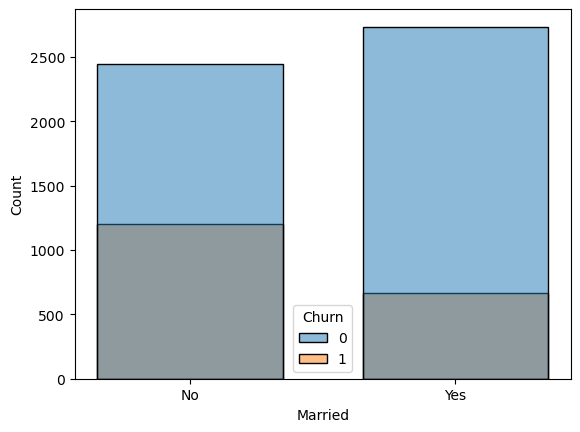

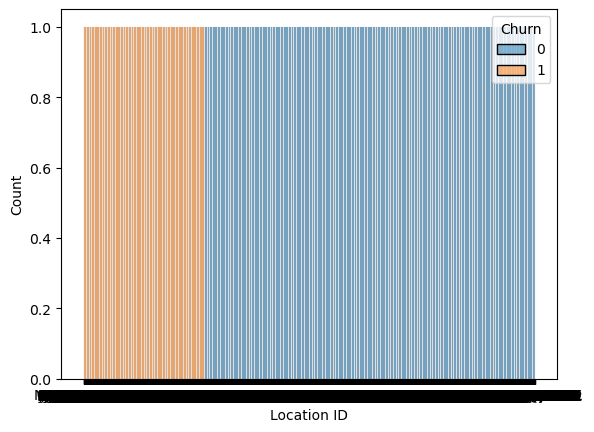

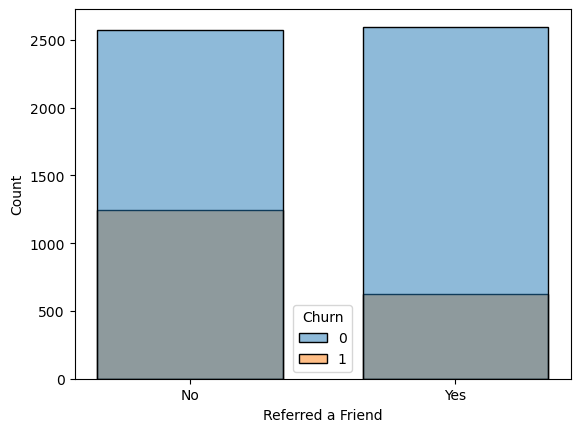

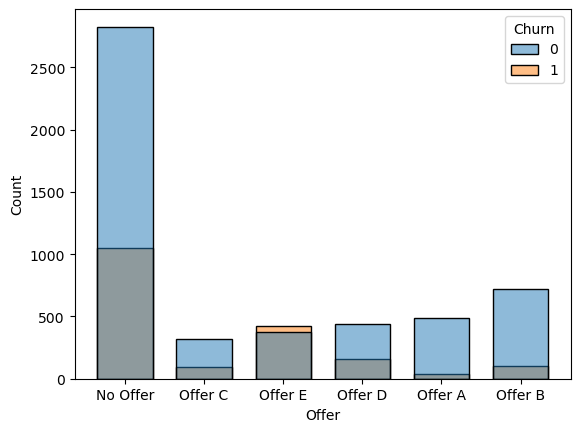

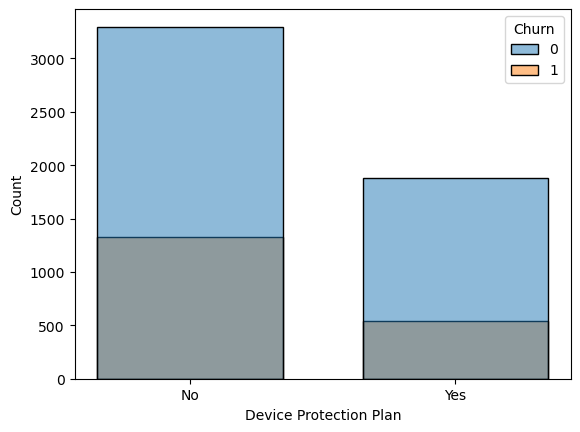

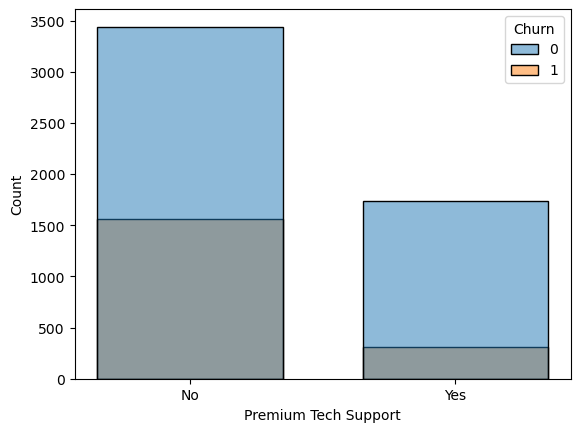

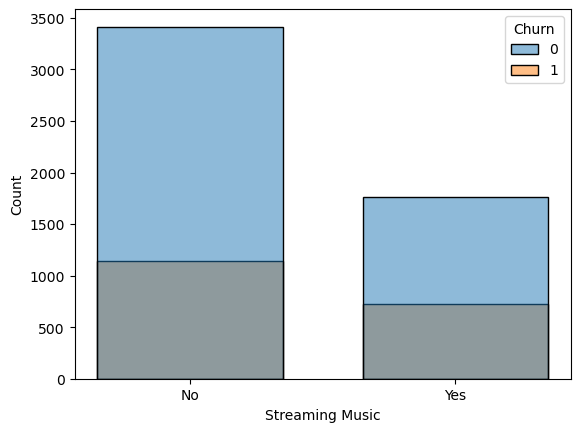

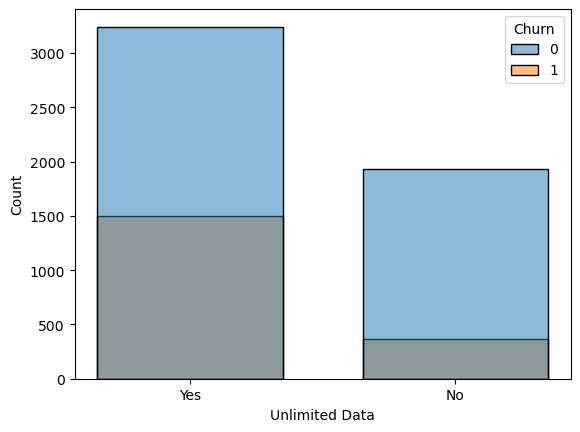

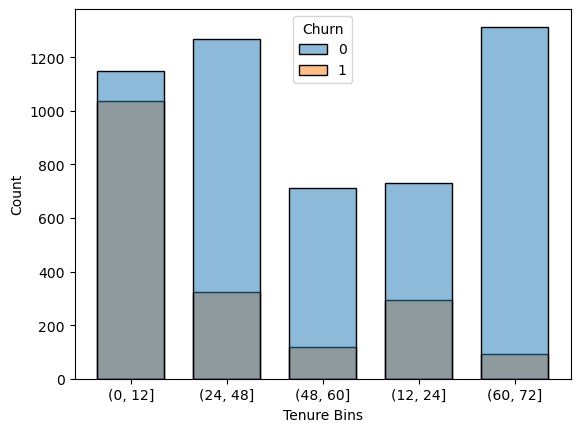

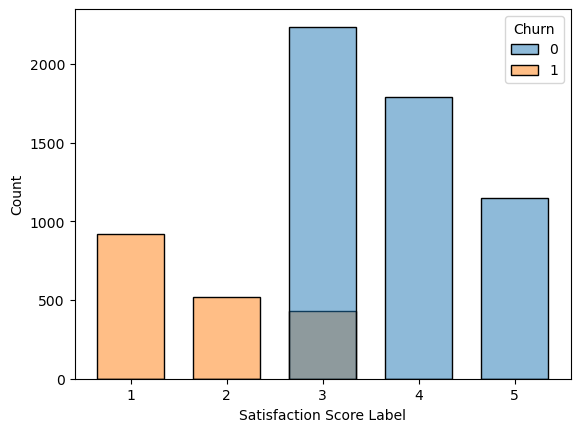

In [51]:
for col in df.columns.tolist() :
    if col !="Churn" and df[col].dtype == 'object':
        plt.figure()
        sns.histplot(df, hue= "Churn",x = col, shrink=0.7 , multiple="layer")
        plt.show()
    elif df[col].dtype == 'category':
        temp = df.copy()
        temp[col] = df[col].astype(str)
        plt.figure()
        sns.histplot(temp, hue="Churn" , x=col , shrink=0.7 , multiple="layer")
        plt.show()

thise gives me an insights into data: however , I realized that this didn't give me a staderdized representaion of my data. for example:  
the disparity in population sies my lead to the misconception that non-senior citizen are 
churning more that senior citizen. thise is primery becuse the non-senior group. however, 
percetage-wise, senior citizen were churning more than non-senior citizen. As shown below

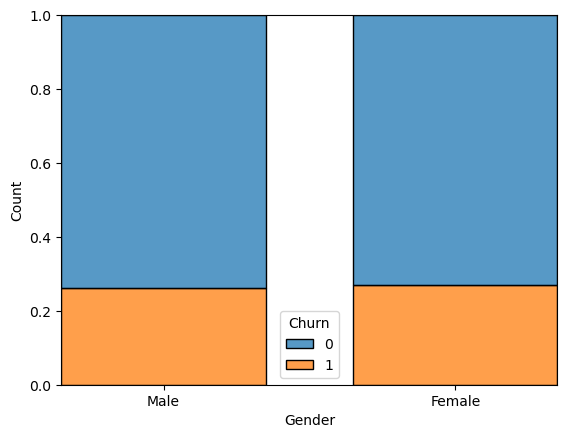

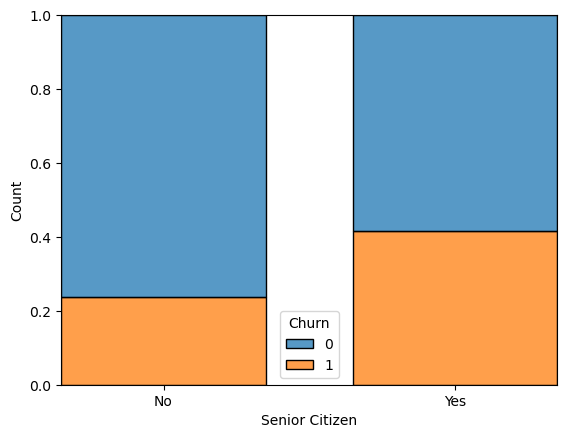

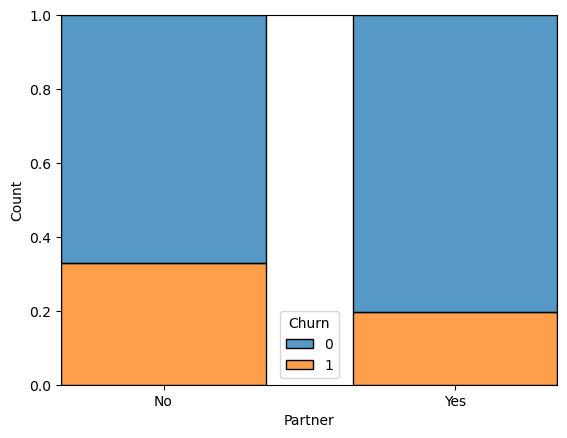

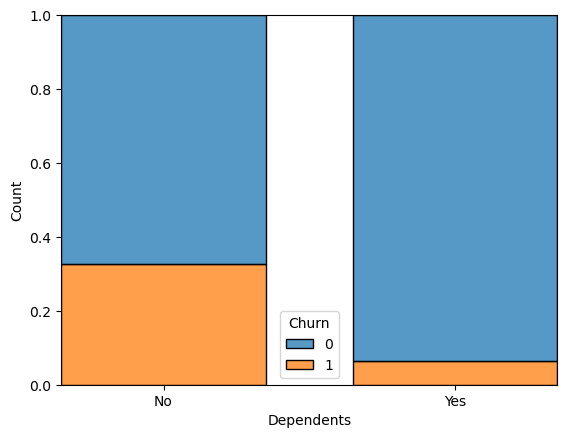

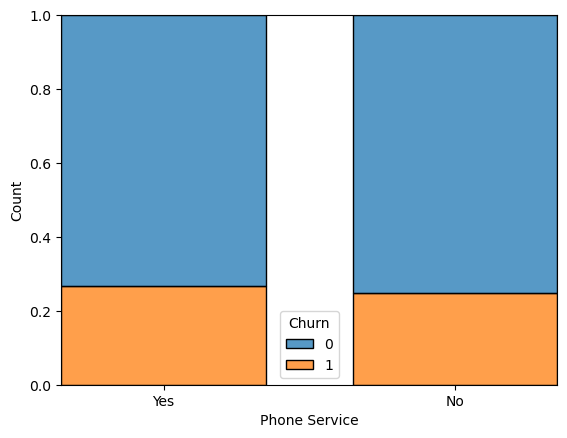

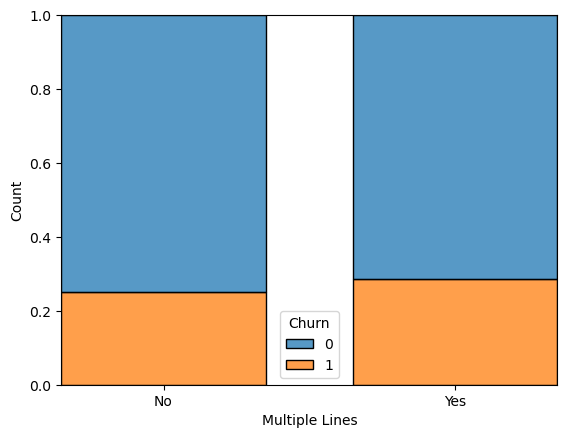

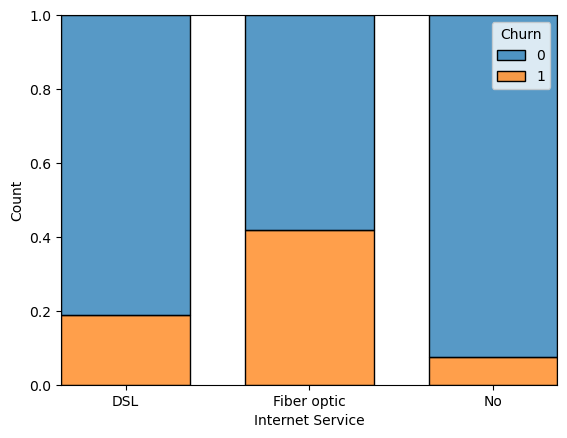

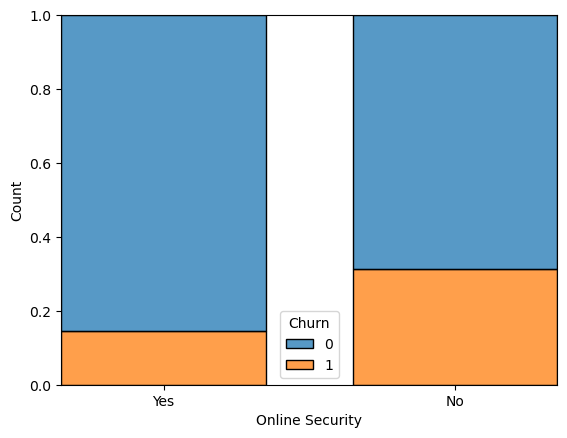

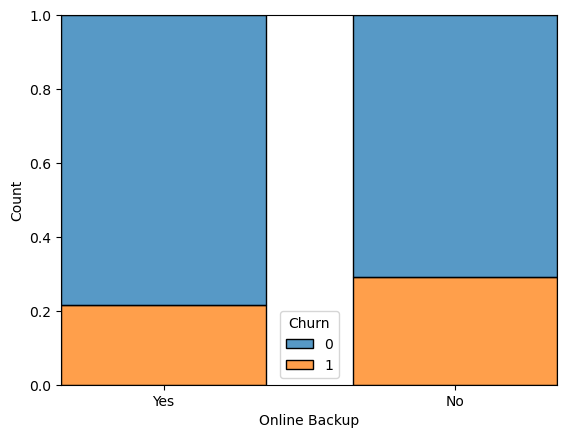

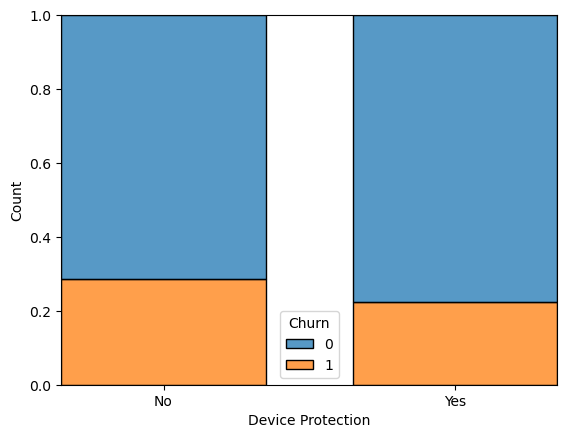

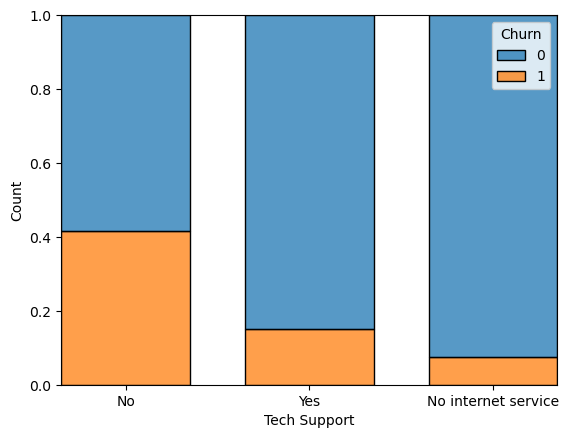

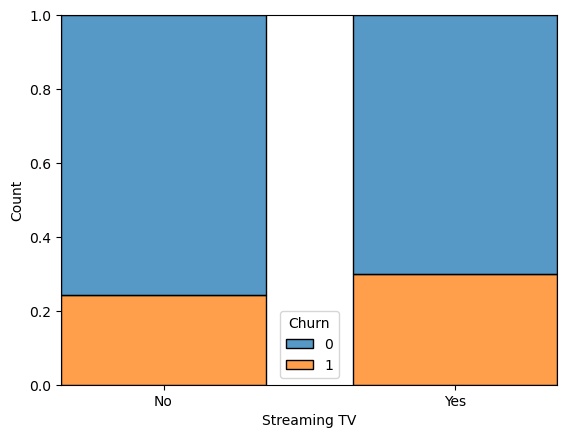

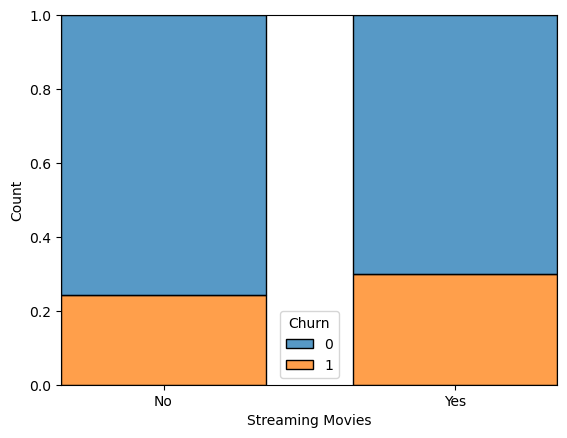

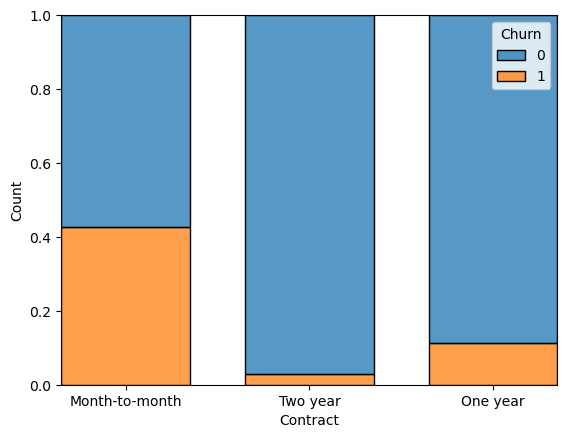

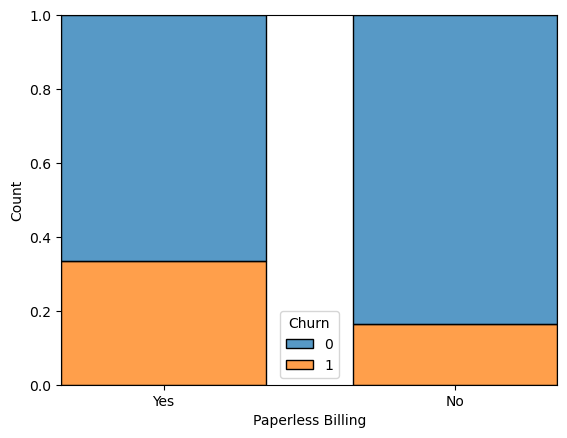

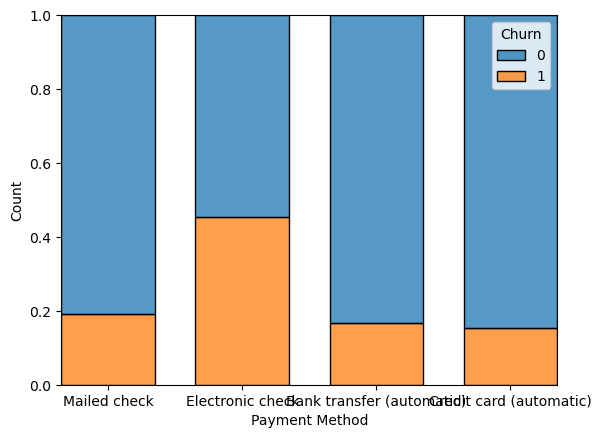

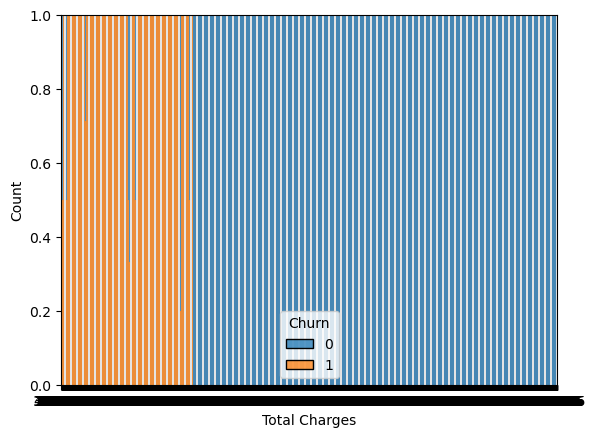

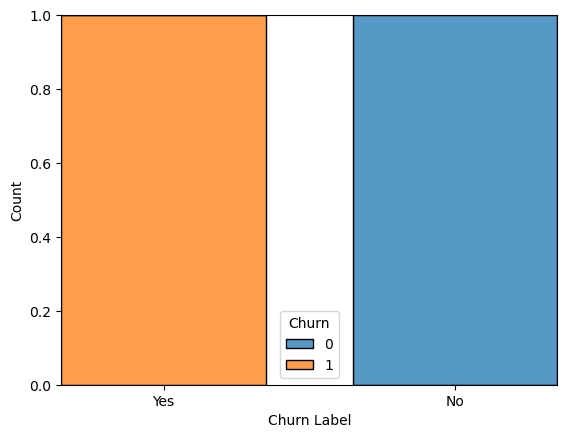

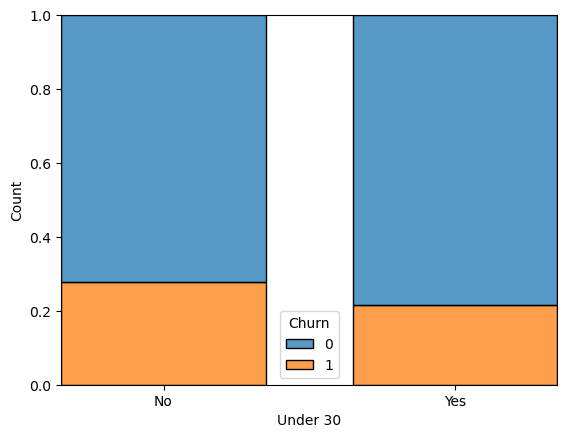

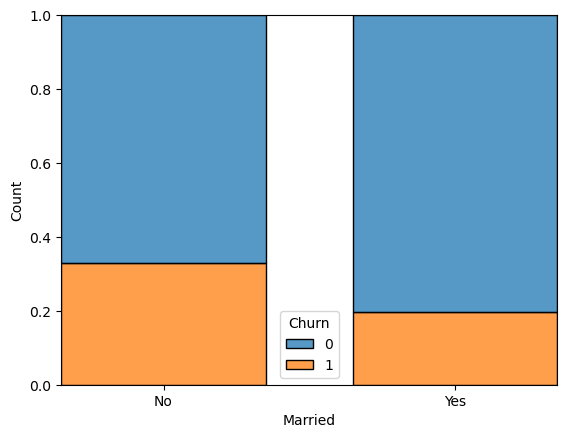

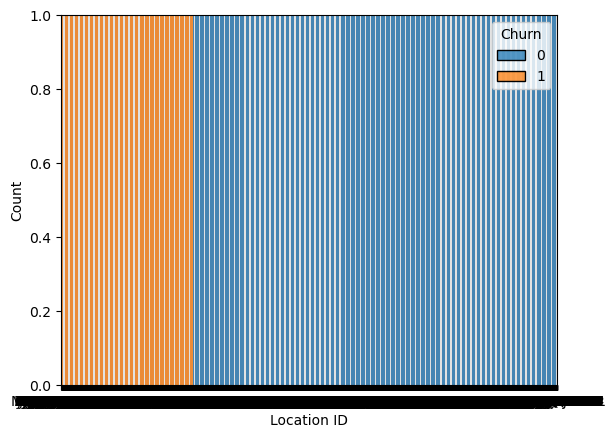

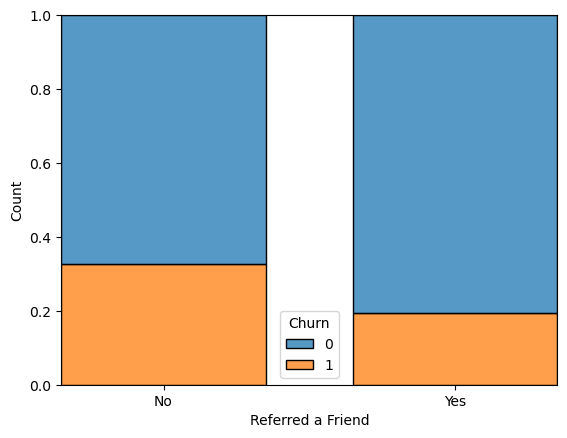

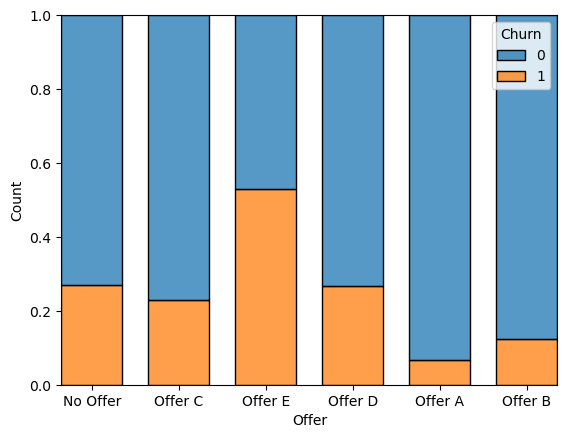

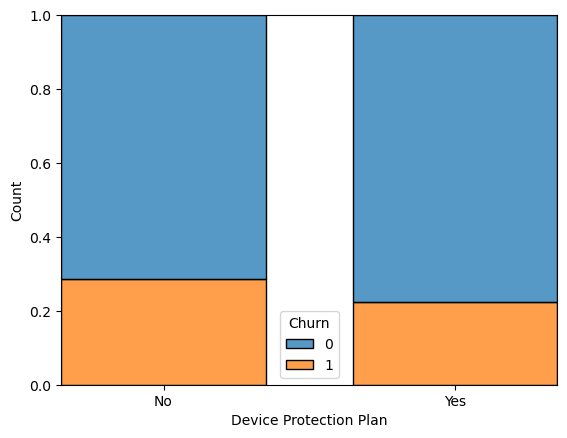

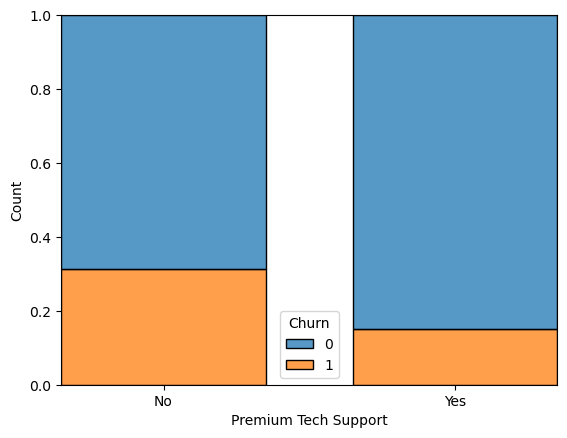

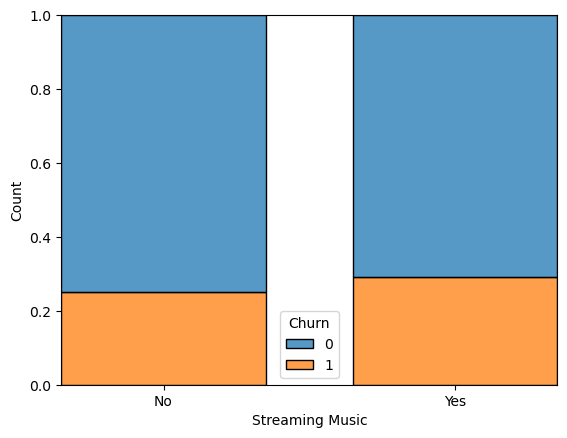

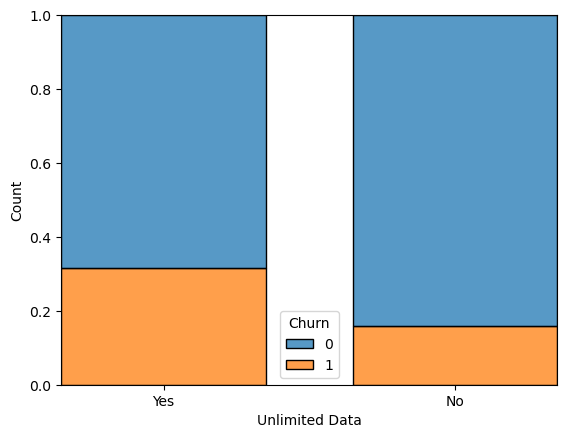

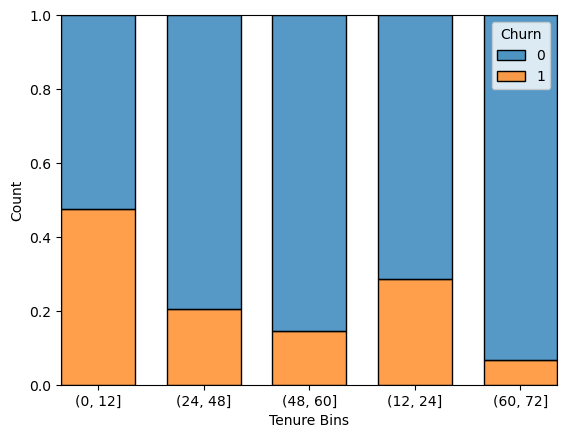

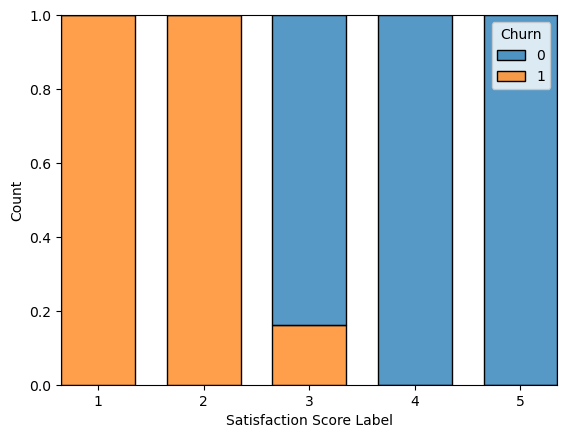

In [52]:
for col in df.columns.tolist() :
    if col != "Churn" and df[col].dtype == 'object':
        plt.Figure()
        sns.histplot(df, hue="Churn", x=col, shrink=0.7 , multiple="fill")
        plt.show()
    elif df[col].dtype == 'category':
        temp = df.copy()
        temp[col] = df[col].astype(str)
        plt.figure()
        sns.histplot(temp , hue="Churn", x=col, shrink=0.7, multiple="fill")

**Obervations:** from the above plotts we can see that:
- "Satification Score Lable" seems to be the biggest indecator of churn as we can see almost anyone who rates our service 1 or 2 most likely to churn so we must reach out to those users to there feedback and resolve any issue, also users with rating 3 also have a chance of shurning. so feedback rating from these users rating frim users must be given very high perforamce 

- "Gender" doesn't seem to play any role in churn 
- "Senior Citizens" seems to churn more than others
- People with No "Dependant" seem to churn more that the ones with "Dependant"
- People with "Fiber Optic" - "Intenet Service" tend ti churn more, these attribute with price
- Users with No "Online Sequrity" or No "Tech Support" tend to churn more should we focus on prvoding better security and tech support
-Users without automatic payment methods tend to more Churning we should take a closer look at that offer
- Customer usign "Months to montshs contarct tend to churn more than others. 
- The higer the "Tenure the lower it have churn seeems to be the egnaral trend.

## Bivariate Analysis 

### Monthly Charges Vs Total Charges

I performed a scatterplot to see how monhly charges varies with total charges and from the plot below, see both attribute have positive relationship.

in simple terms : Thise means as Monthly charges increase the total charges increase, Also we can see as total charges increase Churn (the red dots ) become less.

<Axes: xlabel='Monthly Charges', ylabel='Total Charges'>

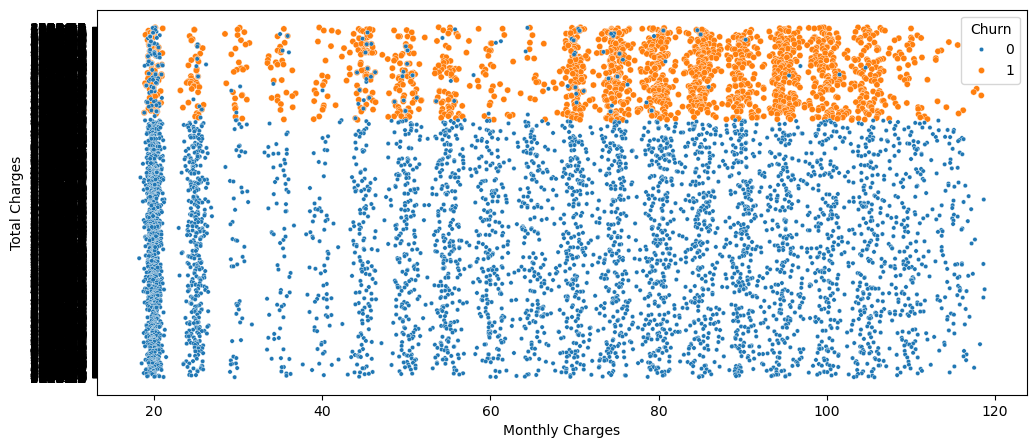

In [54]:
ig = plt.figure(figsize=(12,5))
sns.scatterplot(data = df, x = "Monthly Charges", y = "Total Charges", hue = "Churn", size="Churn", sizes=(20, 10),)

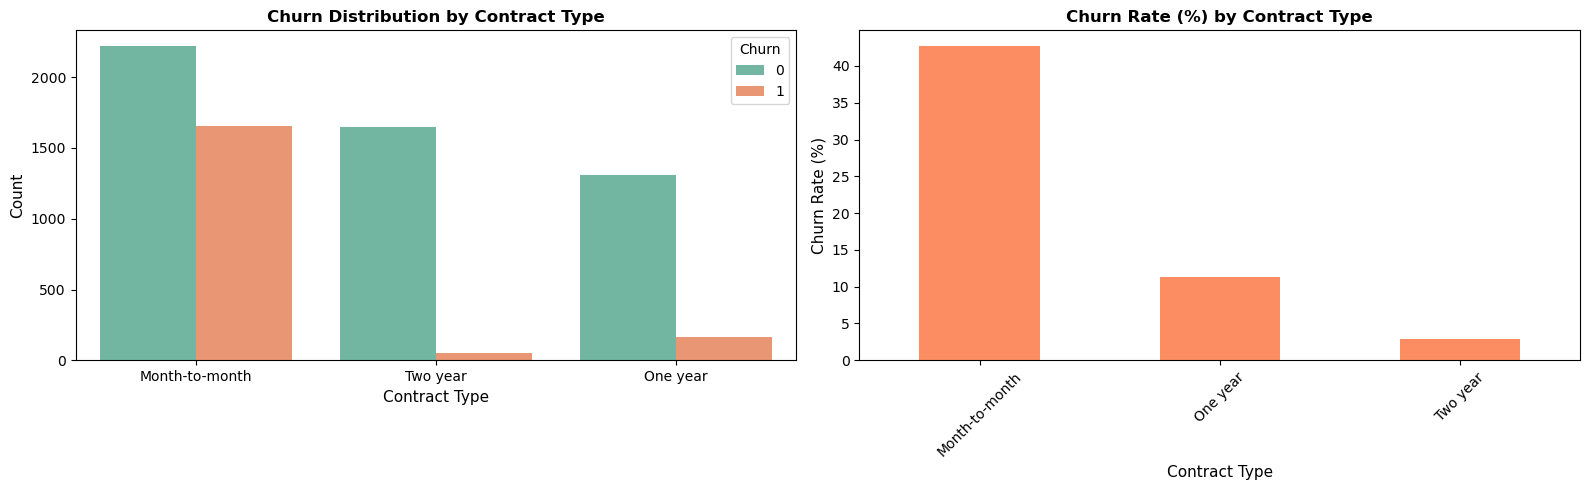

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Count of churn by contract type
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0], palette="Set2")
axes[0].set_title("Churn Distribution by Contract Type", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Contract Type", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)

# Plot 2: Churn rate by contract type
churn_rate = df.groupby("Contract")["Churn"].apply(lambda x: (x == 1).sum() / len(x) * 100)
churn_rate.plot(kind='bar', ax=axes[1], color='#fc8d62')
axes[1].set_title("Churn Rate (%) by Contract Type", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Contract Type", fontsize=11)
axes[1].set_ylabel("Churn Rate (%)", fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**obe